In [2]:
import pandas as pd 
import matplotlib.pyplot as plt
from pathlib import Path
import sqlite3

In [2]:
data_dir = Path(r"C:\Users\Frank\.cache\kagglehub\datasets\rtatman\188-million-us-wildfires\versions\2")
files = list(data_dir.glob("*"))
db_path = files[0]   # adjust if needed after you inspect files
conn = sqlite3.connect(db_path)
query = """
SELECT
    FIRE_YEAR,
    DISCOVERY_DATE,
    CONT_DATE,
    FIRE_SIZE,
    STAT_CAUSE_DESCR,
    STATE,
    COUNTY,
    LATITUDE,
    LONGITUDE
FROM Fires
"""
df = pd.read_sql_query(query, conn)

In [11]:
df.head()

,FIRE_YEAR,DISCOVERY_DATE,CONT_DATE,FIRE_SIZE,STAT_CAUSE_DESCR,STATE,COUNTY,LATITUDE,LONGITUDE,notable_fire,year,month,year_month
0,2005,2005-02-02,2005-02-02,0.10,Miscellaneous,CA,63,40.036944,-121.005833,0,2005,2,2005-02
1,2004,2004-05-12,2004-05-12,0.25,Lightning,CA,61,38.933056,-120.404444,0,2004,5,2004-05
2,2004,2004-05-31,2004-05-31,0.10,Debris Burning,CA,17,38.984167,-120.735556,0,2004,5,2004-05
3,2004,2004-06-28,2004-07-03,0.10,Lightning,CA,3,38.559167,-119.913333,0,2004,6,2004-06
4,2004,2004-06-28,2004-07-03,0.10,Lightning,CA,3,38.559167,-119.933056,0,2004,6,2004-06


In [6]:
df["STATE"] = df["STATE"].astype(str).str.strip()
df["COUNTY"] = df["COUNTY"].astype(str).str.strip()


In [7]:
df["COUNTY"].isna().mean()

np.float64(0.0)

In [19]:
df["notable_fire"] = (df["FIRE_SIZE"] >= 100).astype(int)

In [8]:
df["notable_fire"].mean()

np.float64(0.028765757405748046)

In [20]:
df.shape
df

,FIRE_YEAR,DISCOVERY_DATE,CONT_DATE,FIRE_SIZE,STAT_CAUSE_DESCR,STATE,COUNTY,LATITUDE,LONGITUDE,notable_fire,year,month,year_month
0,2005,2005-02-02,2005-02-02,0.10,Miscellaneous,CA,63,40.036944,-121.005833,0,2005,2,2005-02
1,2004,2004-05-12,2004-05-12,0.25,Lightning,CA,61,38.933056,-120.404444,0,2004,5,2004-05
2,2004,2004-05-31,2004-05-31,0.10,Debris Burning,CA,17,38.984167,-120.735556,0,2004,5,2004-05
3,2004,2004-06-28,2004-07-03,0.10,Lightning,CA,3,38.559167,-119.913333,0,2004,6,2004-06
4,2004,2004-06-28,2004-07-03,0.10,Lightning,CA,3,38.559167,-119.933056,0,2004,6,2004-06
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1880460,2015,2015-09-26,2015-09-26,0.01,Missing/Undefined,CA,None,40.481637,-122.389375,0,2015,9,2015-09
1880461,2015,2015-10-05,NaT,0.20,Miscellaneous,CA,None,37.617619,-120.938570,0,2015,10,2015-10
1880462,2015,2015-05-02,NaT,0.10,Missing/Undefined,CA,None,37.617619,-120.938570,0,2015,5,2015-05
1880463,2015,2015-10-14,NaT,2.00,Missing/Undefined,CA,None,37.672235,-120.898356,0,2015,10,2015-10


In [23]:
df.to_pickle("fire.pkl")


In [4]:
#reload 
df = pd.read_pickle("fire.pkl")

In [9]:

df["DISCOVERY_DATE"] = pd.to_numeric(df["DISCOVERY_DATE"])
df["DISCOVERY_DATE"] = pd.to_datetime(
    df["DISCOVERY_DATE"],
    origin="julian",
    unit="D"
)


df["CONT_DATE"] = pd.to_numeric(df["CONT_DATE"])
df["CONT_DATE"] = pd.to_datetime(
    df["CONT_DATE"],
    origin="julian",
    unit="D"
)

df["year"] = df["DISCOVERY_DATE"].dt.year
df["month"] = df["DISCOVERY_DATE"].dt.month
df["year_month"] = df["DISCOVERY_DATE"].dt.to_period("M")

In [10]:
df.shape

(1880465, 13)

In [12]:
county_month = (
    df.groupby(["STATE", "COUNTY", "year", "month"], dropna=False)
      .agg(
          fire_count=("FIRE_SIZE", "size"),
          notable_fire_count=("notable_fire", "sum"),
          total_acres=("FIRE_SIZE", "sum"),
          max_fire_size=("FIRE_SIZE", "max"),
          mean_fire_size=("FIRE_SIZE", "mean"),
          median_fire_size=("FIRE_SIZE", "median"),
      )
      .reset_index()
)


In [13]:
county_month.head()

,STATE,COUNTY,year,month,fire_count,notable_fire_count,total_acres,max_fire_size,mean_fire_size,median_fire_size
0,AK,020,2010,7,1,0,0.1,0.1,0.1,0.1
1,AK,110,1997,5,1,0,2.0,2.0,2.0,2.0
2,AK,110,2005,3,1,0,1.0,1.0,1.0,1.0
3,AK,110,2005,4,2,0,0.2,0.1,0.1,0.1
4,AK,110,2005,5,3,0,2.7,2.5,0.9,0.1


In [16]:
county_month.shape
county_month.to_pickle("county.pkl")

In [32]:
county_month["target"] = (county_month["notable_fire_count"] > 0).astype(int)

In [ ]:
# All the variabels like total_acres, max_fire_size, mean_fire_size, median_fire_size maybe introduces leakage 

county_month = county_month.copy()

print("Rows:", len(county_month))
print("States:", county_month["STATE"].nunique())
print("Counties:", county_month[["STATE", "COUNTY"]].drop_duplicates().shape[0])
print("Year range:", county_month["year"].min(), "-", county_month["year"].max())

county_month["target"] = (county_month["notable_fire_count"] > 0).astype(int)

print("\nTarget rate:")
print(county_month["target"].mean())

print("\nfire_count summary:")
print(county_month["fire_count"].describe())

print("\nnotable_fire_count summary:")
print(county_month["notable_fire_count"].describe())

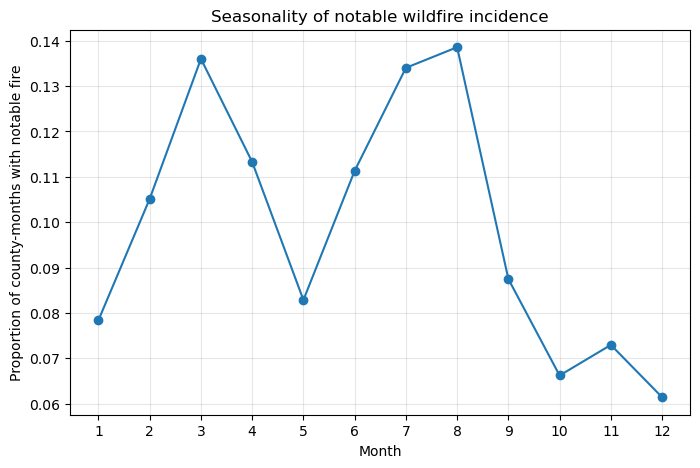

In [39]:
monthly = county_month.groupby("month")["target"].mean()

plt.figure(figsize=(8, 5))
monthly.plot(marker="o")
plt.xlabel("Month")
plt.ylabel("Proportion of county-months with notable fire")
plt.title("Seasonality of notable wildfire incidence")
plt.xticks(range(1, 13))
plt.grid(True, alpha=0.3)
plt.show()

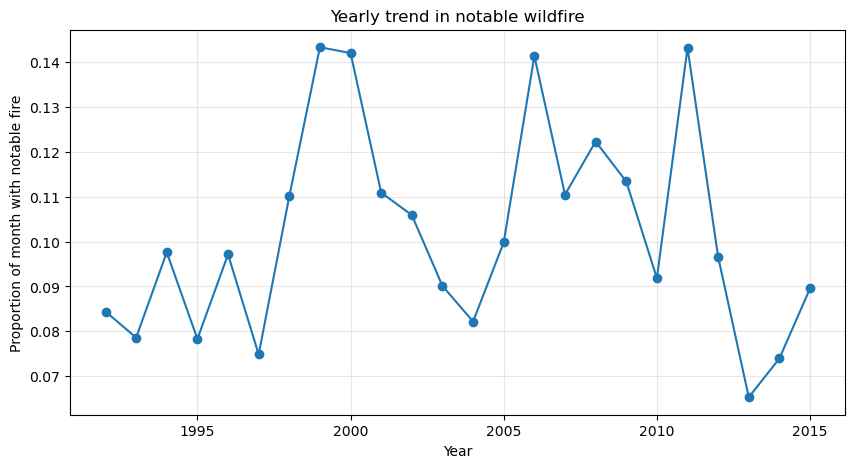

In [67]:
yearly = county_month.groupby("year")["target"].mean()

plt.figure(figsize=(10, 5))
yearly.plot(marker="o")
plt.xlabel("Year")
plt.ylabel("Proportion of months with notable fire") #out of all fire incidences?
plt.title("Yearly trend in notable wildfire")
plt.grid(True, alpha=0.3)
plt.show()


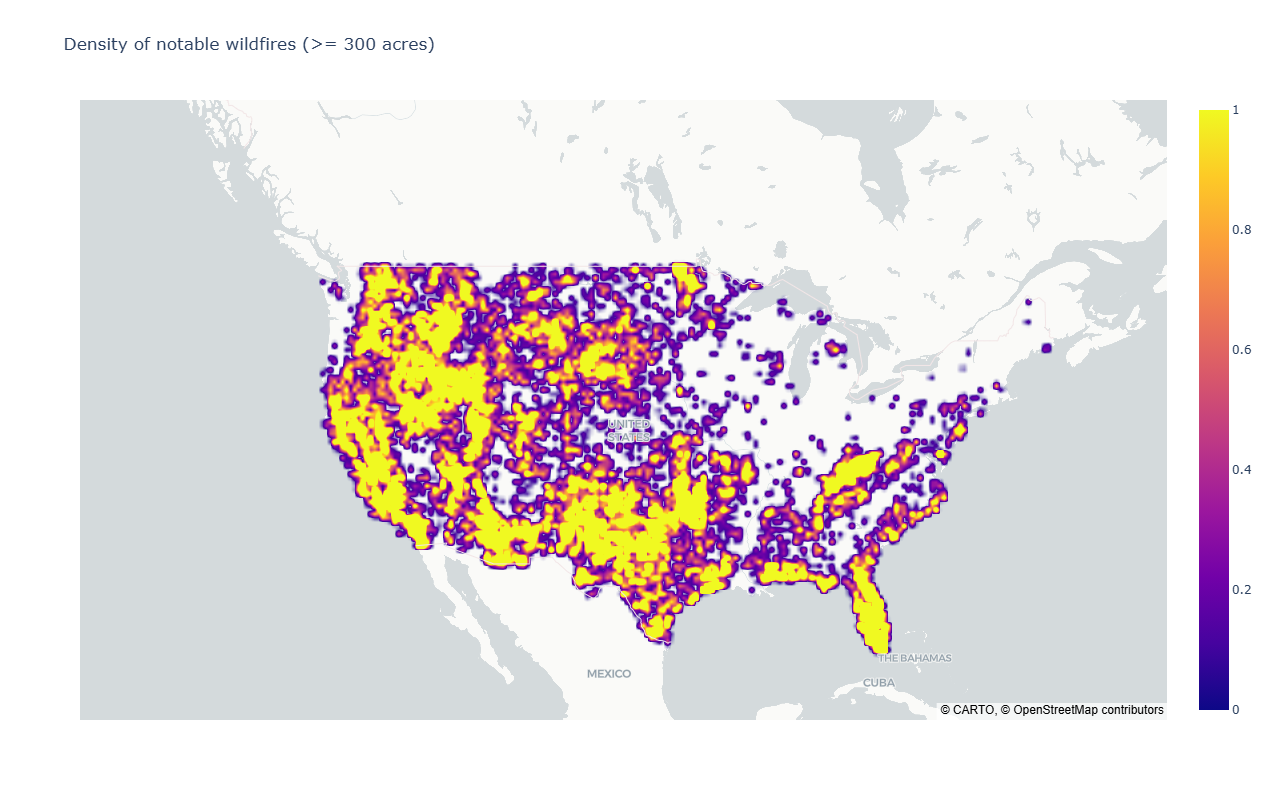

In [61]:
import plotly.express as px
notable = df[df["FIRE_SIZE"] >= 300].copy()
fig = px.density_map(
    notable,
    lat="LATITUDE",
    lon="LONGITUDE",
    z=None,
    radius=4,
    center=dict(lat=39, lon=-98),
    zoom=3,
    map_style="carto-positron",
    title="Density of notable wildfires (>= 300 acres)"
)
#fig.update_layout(width=3600, height=2400)
fig.update_layout(width=1200, height=800)
fig.show()

#use wildfire data cluster 
#Use week 9 model TA 

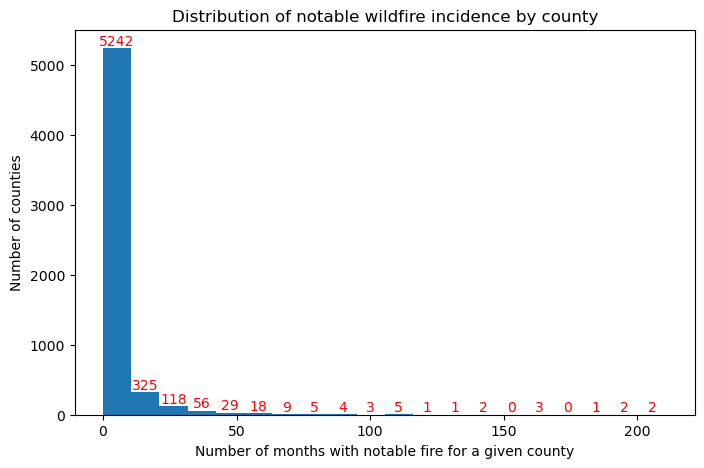

In [76]:
county_summary = (
    county_month.groupby(["STATE", "COUNTY"])
    .agg(
        total_months=("target", "size"),
        positive_months=("target", "sum"),
        total_fires=("fire_count", "sum"),
        total_notable=("notable_fire_count", "sum")
    )
    .reset_index()
)
plt.figure(figsize=(8, 5))
counts, bins, patches = plt.hist(county_summary["positive_months"], bins=20)
for count, patch in zip(counts, patches):
    x = patch.get_x() + patch.get_width() / 2
    y = patch.get_height()
    plt.text(x, y, int(count), ha="center", va="bottom",color="red")
plt.xlabel("Number of months with notable fire for a given county")
plt.ylabel("Number of counties")
plt.title("Distribution of notable wildfire incidence by county")
plt.show()